# Segmentation Robustness Checks

K-Means with k=5 is the current candidate final segmentation. This notebook checks whether that choice is stable and reasonable before finalising the segmentation decision. It does not refit or overwrite `outputs/customer_clusters.csv`.

## Load Data

In [ ]:
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42
SILHOUETTE_SAMPLE_SIZE = 10000
N_INIT = 20
PALETTE = ["#356D8C", "#5C8A72", "#C9822B", "#7C6FA4", "#B4514E", "#4F8F8B"]


In [ ]:
selected_model_features = pd.read_csv("../data/processed/selected_model_features.csv")

model_features = selected_model_features.drop(columns=["customer_id"])
non_numeric_columns = model_features.select_dtypes(exclude="number").columns.tolist()

input_validation = pd.DataFrame(
    {
        "check": [
            "customer_id exists",
            "duplicated customer_id count",
            "missing values count",
            "non-numeric modelling columns",
            "row count",
            "modelling feature count",
        ],
        "value": [
            "customer_id" in selected_model_features.columns,
            selected_model_features["customer_id"].duplicated().sum(),
            selected_model_features.isna().sum().sum(),
            non_numeric_columns,
            len(selected_model_features),
            model_features.shape[1],
        ],
    }
)

if "customer_id" not in selected_model_features.columns:
    raise ValueError("customer_id is missing from selected_model_features.csv")
if selected_model_features["customer_id"].duplicated().sum() > 0:
    raise ValueError("Duplicated customer_id values found.")
if selected_model_features.isna().sum().sum() > 0:
    raise ValueError("Missing values found in selected_model_features.csv.")
if non_numeric_columns:
    raise ValueError(f"Non-numeric modelling columns found: {non_numeric_columns}")

input_validation


,check,value
0,customer_id exists,True
1,duplicated customer_id count,0
2,missing values count,0
3,non-numeric modelling columns,[]
4,row count,33038
5,modelling feature count,25


The selected model feature table is already scaled and encoded. `customer_id` is kept only for validation and is excluded from K-Means fitting.

## Baseline K-Means k Comparison

In [ ]:
def calculate_kmeans_metrics(X, labels, k, check_type, variant, random_state=RANDOM_STATE):
    cluster_counts = pd.Series(labels).value_counts()
    silhouette_sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(X))

    return {
        "check_type": check_type,
        "variant": variant,
        "k": k,
        "random_state": random_state,
        "n_features": X.shape[1],
        "silhouette_score": silhouette_score(
            X,
            labels,
            sample_size=silhouette_sample_size,
            random_state=RANDOM_STATE,
        ),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels),
        "min_cluster_size": int(cluster_counts.min()),
        "max_cluster_size": int(cluster_counts.max()),
        "min_cluster_percentage": cluster_counts.min() / len(labels) * 100,
        "max_cluster_percentage": cluster_counts.max() / len(labels) * 100,
    }


baseline_rows = []

for k in [3, 4, 5, 6, 7, 8]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels = kmeans.fit_predict(model_features)
    baseline_rows.append(
        calculate_kmeans_metrics(
            model_features,
            labels,
            k=k,
            check_type="baseline_k_comparison",
            variant="current_selected_features",
        )
    )

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_metrics.to_csv("../outputs/segmentation_robustness_metrics.csv", index=False)
baseline_metrics


,check_type,variant,k,random_state,n_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
0,baseline_k_comparison,current_selected_features,3,42,25,0.133191,4058.291747,2.129160,5808,20664,17.579757,62.546159
1,baseline_k_comparison,current_selected_features,4,42,25,0.124430,3842.372837,2.266765,4715,11199,14.271445,33.897330
2,baseline_k_comparison,current_selected_features,5,42,25,0.135232,3650.808484,2.108625,2234,10843,6.761911,32.819783
3,baseline_k_comparison,current_selected_features,6,42,25,0.127300,3402.130784,2.096148,2006,9837,6.071796,29.774805
4,baseline_k_comparison,current_selected_features,7,42,25,0.112778,3194.764317,2.065851,1898,7774,5.744900,23.530480
5,baseline_k_comparison,current_selected_features,8,42,25,0.121967,3056.038449,2.030153,1764,6028,5.339306,18.245657


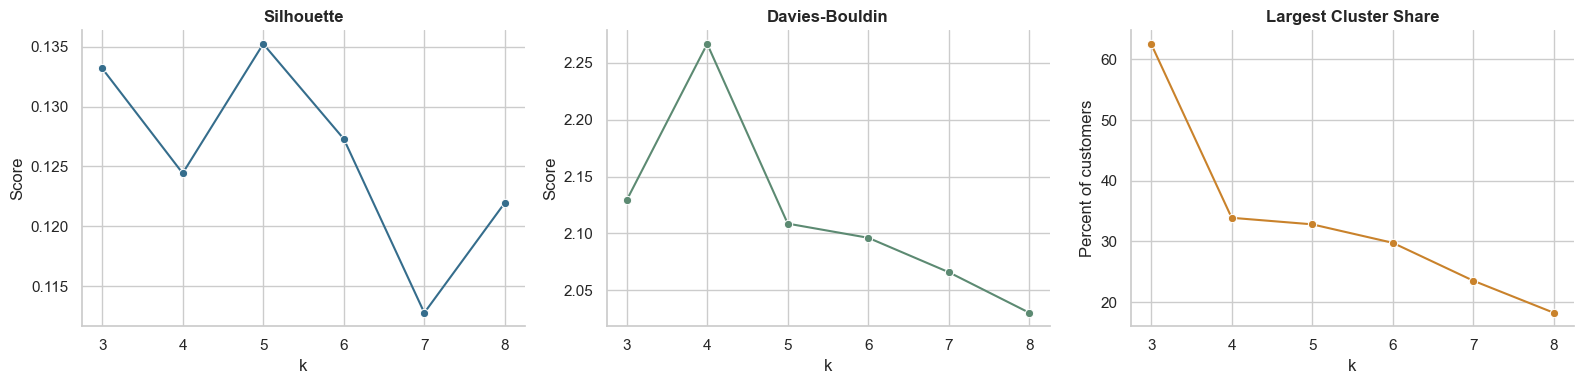

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=baseline_metrics, x="k", y="silhouette_score", marker="o", color=PALETTE[0], ax=axes[0])
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Score")

sns.lineplot(data=baseline_metrics, x="k", y="davies_bouldin_score", marker="o", color=PALETTE[1], ax=axes[1])
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

sns.lineplot(data=baseline_metrics, x="k", y="max_cluster_percentage", marker="o", color=PALETTE[2], ax=axes[2])
axes[2].set_title("Largest Cluster Share")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Percent of customers")

plt.tight_layout()
plt.show()


The baseline comparison checks whether k=5 still looks reasonable against nearby alternatives. Silhouette is sampled for runtime practicality, while Calinski-Harabasz, Davies-Bouldin, and cluster balance use all rows.

## Seed Stability Test

In [ ]:
seed_rows = []
seeds = [0, 21, 42, 99, 123]

for k in [4, 5, 6]:
    labels_by_seed = {}
    for seed in seeds:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=N_INIT)
        labels_by_seed[seed] = kmeans.fit_predict(model_features)

    for seed_a, seed_b in combinations(seeds, 2):
        seed_rows.append(
            {
                "k": k,
                "seed_a": seed_a,
                "seed_b": seed_b,
                "adjusted_rand_index": adjusted_rand_score(labels_by_seed[seed_a], labels_by_seed[seed_b]),
            }
        )

segmentation_seed_stability = pd.DataFrame(seed_rows)
segmentation_seed_stability.to_csv("../outputs/segmentation_seed_stability.csv", index=False)
segmentation_seed_stability


,k,seed_a,seed_b,adjusted_rand_index
0,4,0,21,0.997555
1,4,0,42,0.995958
2,4,0,99,0.998146
3,4,0,123,0.996793
4,4,21,42,0.995839
5,4,21,99,0.998618
6,4,21,123,0.997068
7,4,42,99,0.996430
8,4,42,123,0.995597
9,4,99,123,0.998251


In [ ]:
seed_stability_summary = (
    segmentation_seed_stability.groupby("k")["adjusted_rand_index"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

seed_stability_summary


,k,mean,min,max
0,4,0.997026,0.995597,0.998618
1,5,0.998027,0.996895,0.999660
2,6,0.998844,0.997713,1.000000


Adjusted Rand Index compares whether different random seeds produce similar assignments. Values close to 1 indicate that the segmentation is stable across seeds.

## Simple Feature Sensitivity Checks

In [ ]:
feature_variants = {"current_selected_features": model_features}
skipped_variants = []

if all(column in model_features.columns for column in ["latitude", "longitude"]):
    feature_variants["without_latitude_longitude"] = model_features.drop(columns=["latitude", "longitude"])
else:
    skipped_variants.append("without_latitude_longitude: latitude/longitude are not in selected_model_features")

if "total_lifetime_spend" in model_features.columns:
    feature_variants["without_total_lifetime_spend"] = model_features.drop(columns=["total_lifetime_spend"])
else:
    skipped_variants.append("without_total_lifetime_spend: total_lifetime_spend is not in selected_model_features")

if all(column in model_features.columns for column in ["latitude", "longitude", "total_lifetime_spend"]):
    feature_variants["without_latitude_longitude_total_lifetime_spend"] = model_features.drop(
        columns=["latitude", "longitude", "total_lifetime_spend"]
    )
else:
    skipped_variants.append(
        "without_latitude_longitude_total_lifetime_spend: latitude/longitude are not in selected_model_features"
    )

feature_variant_summary = pd.DataFrame(
    {
        "variant": list(feature_variants.keys()),
        "n_features": [features.shape[1] for features in feature_variants.values()],
    }
)

feature_variant_summary


,variant,n_features
0,current_selected_features,25
1,without_total_lifetime_spend,24


In [ ]:
pd.DataFrame({"skipped_variant": skipped_variants})


,skipped_variant
0,without_latitude_longitude: latitude/longitude...
1,without_latitude_longitude_total_lifetime_spen...


In [ ]:
sensitivity_rows = []

for variant_name, variant_features in feature_variants.items():
    for k in [4, 5, 6]:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        labels = kmeans.fit_predict(variant_features)
        sensitivity_rows.append(
            calculate_kmeans_metrics(
                variant_features,
                labels,
                k=k,
                check_type="feature_sensitivity",
                variant=variant_name,
            )
        )

feature_sensitivity_metrics = pd.DataFrame(sensitivity_rows)
segmentation_robustness_metrics = pd.concat(
    [baseline_metrics, feature_sensitivity_metrics],
    ignore_index=True,
)
segmentation_robustness_metrics.to_csv("../outputs/segmentation_robustness_metrics.csv", index=False)
feature_sensitivity_metrics


,check_type,variant,k,random_state,n_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
0,feature_sensitivity,current_selected_features,4,42,25,0.124430,3842.372837,2.266765,4715,11199,14.271445,33.897330
1,feature_sensitivity,current_selected_features,5,42,25,0.135232,3650.808484,2.108625,2234,10843,6.761911,32.819783
2,feature_sensitivity,current_selected_features,6,42,25,0.127300,3402.130784,2.096148,2006,9837,6.071796,29.774805
3,feature_sensitivity,without_total_lifetime_spend,4,42,24,0.110357,3707.839728,2.360821,4751,11433,14.380410,34.605606
4,feature_sensitivity,without_total_lifetime_spend,5,42,24,0.122626,3553.786227,2.182205,2156,10946,6.525819,33.131545
5,feature_sensitivity,without_total_lifetime_spend,6,42,24,0.128181,3361.910288,2.079041,2093,12322,6.335129,37.296447


Latitude and longitude are already excluded from `selected_model_features.csv`, so geography-removal variants are skipped. The simple sensitivity check therefore compares the current feature set against the same set without `total_lifetime_spend`.

## Business Interpretability Check

In [ ]:
business_check = baseline_metrics[baseline_metrics["k"].isin([4, 5, 6])].merge(
    seed_stability_summary,
    on="k",
    how="left",
    suffixes=("", "_seed_stability"),
)

business_check[[
    "k",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_percentage",
    "max_cluster_percentage",
    "mean",
    "min",
]]


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_percentage,max_cluster_percentage,mean,min
0,4,0.124430,3842.372837,2.266765,14.271445,33.897330,0.997026,0.995597
1,5,0.135232,3650.808484,2.108625,6.761911,32.819783,0.998027,0.996895
2,6,0.127300,3402.130784,2.096148,6.071796,29.774805,0.998844,0.997713


k=4 has cleaner minimum cluster size than k=5, but it has weaker silhouette and the weakest Davies-Bouldin score among the main candidates. k=5 has the strongest silhouette among k=3 through k=8 and a stable largest cluster share around one third of customers. k=6 improves balance slightly and has a similar Davies-Bouldin score, so it deserves attention, but it does not clearly beat k=5 on the main quality metrics. Seed stability is very high for k=4, k=5, and k=6, which means the nearby segmentations are not fragile random initialisation artifacts.

## Recommendation

In [ ]:
def baseline_value(k, column):
    return baseline_metrics.loc[baseline_metrics["k"] == k, column].iloc[0]


def stability_value(k, column):
    return seed_stability_summary.loc[seed_stability_summary["k"] == k, column].iloc[0]


recommendation = pd.DataFrame(
    [
        {
            "candidate": "K-Means k=4",
            "evidence_for": f"Minimum cluster share is {baseline_value(4, 'min_cluster_percentage'):.1f}%, so no segment is tiny.",
            "evidence_against": f"Silhouette is {baseline_value(4, 'silhouette_score'):.3f} and Davies-Bouldin is {baseline_value(4, 'davies_bouldin_score'):.3f}, weaker than k=5.",
            "recommendation": "Not preferred; useful as a simpler fallback only.",
        },
        {
            "candidate": "K-Means k=5",
            "evidence_for": f"Best baseline silhouette at {baseline_value(5, 'silhouette_score'):.3f}; largest cluster share is {baseline_value(5, 'max_cluster_percentage'):.1f}%; mean seed ARI is {stability_value(5, 'mean'):.3f}.",
            "evidence_against": f"Smallest cluster share is {baseline_value(5, 'min_cluster_percentage'):.1f}%, so one segment is relatively small and needs business interpretation.",
            "recommendation": "Still supported as the practical final candidate, with k=6 noted as the closest alternative.",
        },
        {
            "candidate": "K-Means k=6",
            "evidence_for": f"Largest cluster share falls to {baseline_value(6, 'max_cluster_percentage'):.1f}% and seed stability is very high, with mean ARI {stability_value(6, 'mean'):.3f}.",
            "evidence_against": f"Silhouette falls to {baseline_value(6, 'silhouette_score'):.3f} and Calinski-Harabasz is lower than k=5.",
            "recommendation": "Worth reviewing in the final discussion, but not enough evidence to replace k=5 now.",
        },
    ]
)

recommendation.to_csv("../outputs/segmentation_robustness_recommendation.csv", index=False)
recommendation


,candidate,evidence_for,evidence_against,recommendation
0,K-Means k=4,"Minimum cluster share is 14.3%, so no segment ...",Silhouette is 0.124 and Davies-Bouldin is 2.26...,Not preferred; useful as a simpler fallback only.
1,K-Means k=5,Best baseline silhouette at 0.135; largest clu...,"Smallest cluster share is 6.8%, so one segment...",Still supported as the practical final candida...
2,K-Means k=6,Largest cluster share falls to 29.8% and seed ...,Silhouette falls to 0.127 and Calinski-Harabas...,"Worth reviewing in the final discussion, but n..."


The robustness check supports k=5, but not blindly: k=6 is close enough to mention as an alternative in the final report. The current `outputs/customer_clusters.csv` is not overwritten in this phase.

## Final Output Check

In [ ]:
output_check = pd.DataFrame(
    {
        "output": [
            "outputs/segmentation_robustness_metrics.csv",
            "outputs/segmentation_seed_stability.csv",
            "outputs/segmentation_robustness_recommendation.csv",
        ],
        "rows": [
            len(segmentation_robustness_metrics),
            len(segmentation_seed_stability),
            len(recommendation),
        ],
    }
)

output_check


,output,rows
0,outputs/segmentation_robustness_metrics.csv,12
1,outputs/segmentation_seed_stability.csv,30
2,outputs/segmentation_robustness_recommendation...,3
